# Lung atlas (K=13, fine-grained cell types) -- Stack+Pool vs. Pool+Stack

All 8 methods together, on purpose: this is the one notebook where both
pooled variants appear side by side, each with a distinguishing name instead
of the ambiguous shared "Pooled" used in `aggregate_and_plot_paper.ipynb` /
`aggregate_and_plot_new_pooled.ipynb` (which each only ever show one variant):

- **Stack+Pool** (`pooled_concat`, the original arXiv:2607.25031 estimator):
  **stack** the raw target+source data (row-concatenate) first, then **pool**
  it all into one joint clustering computation.
- **Pool+Stack** (`target_source_pooled`, the newer estimator): **pool**
  (estimate) a direction from each dataset separately first -- the target's
  own, plus each source's -- then **stack** those estimated direction vectors
  together into the joint projection subspace.

The name order reflects which operation happens first in each method's
pipeline. Reads `results_0.5_alpha/raw/*.csv`, reproduces the combined
ARI/V-measure/misclustering LaTeX table and misclustering/ARI bar charts for
all 8 methods.

Standalone and read-only with respect to `results_0.5_alpha/raw/` -- rerun any
time after adding/replacing files there. Outputs land in
`results_0.5_alpha/stack_pool/`: `lung_atlas_comparison_results.csv`,
`lung_atlas_combined_table.tex`, `lung_atlas_misclustering.pdf`,
`lung_atlas_ari.pdf`.

In [1]:
import glob, os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import common

## Load and combine

Reads every `results_0.5_alpha/raw/*.csv` (all 8 methods) and checks
completeness against the expected 80-row grid before doing anything else.

In [2]:
RESULTS_DIR = "results_0.5_alpha"
RAW_DIR = os.path.join(RESULTS_DIR, "raw")
OUT_DIR = os.path.join(RESULTS_DIR, "stack_pool")
os.makedirs(OUT_DIR, exist_ok=True)

raw_paths = sorted(glob.glob(os.path.join(RAW_DIR, "*.csv")))
print(f"Found {len(raw_paths)} raw result files in {RAW_DIR}")
assert raw_paths, f"No CSVs found in {RAW_DIR}"

INCLUDED_METHODS = list(common.METHOD_LABELS.keys())  # all 8
LABELS = dict(common.METHOD_LABELS)
LABELS["pooled_concat"] = "Stack+Pool"
LABELS["target_source_pooled"] = "Pool+Stack"

MULTI_SOURCE_METHODS = {
    "multi_source_pooled", "pooled_concat", "target_source_pooled", "adaptive_multi_source",
}


def expected_grid():
    """Mirrors run_lung_atlas_comparison.py's task_grid()."""
    grid = set()
    for target in common.BATCHES:
        others = [b for b in common.BATCHES if b != target]
        for method in INCLUDED_METHODS:
            if method == "target_only":
                grid.add((target, method, "none"))
            elif method in MULTI_SOURCE_METHODS:
                grid.add((target, method, "all"))
                for src in others:
                    grid.add((target, method, src))
            else:
                grid.add((target, method, "all"))
    return grid


expected = expected_grid()
found = set()
rows = []
for path in raw_paths:
    row = pd.read_csv(path).iloc[0]
    rows.append(row.to_dict())
    found.add((row["target"], row["method"], row["source"]))

missing = expected - found
if missing:
    print(f"WARNING: {len(missing)}/{len(expected)} (target, method, source) results missing from {RAW_DIR}:")
    for target, method, source in sorted(missing):
        print(f"  {target}, {method}, {source}")
else:
    print(f"All {len(expected)} (target, method, source) combinations present")

results = pd.DataFrame(rows)
combined_path = os.path.join(OUT_DIR, "lung_atlas_comparison_results.csv")
results.to_csv(combined_path, index=False)
print(f"Wrote {combined_path}")

results_all = results[results["source"].isin(["all", "none"])].reset_index(drop=True)
results_all

Found 80 raw result files in results_0.5_alpha/raw


All 80 (target, method, source) combinations present
Wrote results_0.5_alpha/stack_pool/lung_atlas_comparison_results.csv


,target,method,source,elapsed_sec,misclustering,ari,v_measure
0,Dropseq_1,adaptive_multi_source,all,974.294318,0.459009,0.455743,0.681196
1,Dropseq_1,gdec_gcnfree,all,1013.851493,0.641087,0.284914,0.480034
2,Dropseq_1,multi_source_pooled,all,265.920643,0.507150,0.431597,0.653114
3,Dropseq_1,pooled_concat,all,6435.814324,0.449952,0.451203,0.666754
4,Dropseq_1,scrna,all,4.045965,0.660153,0.000000,0.000000
5,Dropseq_1,target_only,none,55.677046,0.459009,0.455743,0.681196
6,Dropseq_1,target_source_pooled,all,389.644481,0.457102,0.460325,0.684595
7,Dropseq_1,tlgmm,all,370.461665,0.444709,0.443325,0.655267
8,Dropseq_2,adaptive_multi_source,all,1489.833962,0.508954,0.363136,0.618400
9,Dropseq_2,gdec_gcnfree,all,897.994371,0.603205,0.281803,0.401393


## Summary tables (method x target batch)

In [3]:
for metric in ["misclustering", "ari", "v_measure"]:
    print(f"\n--- {metric} ---")
    display(results_all.pivot(index="method", columns="target", values=metric)
                        .reindex(index=INCLUDED_METHODS, columns=common.BATCHES))


--- misclustering ---


target,Dropseq_1,Dropseq_2,Dropseq_3,Dropseq_4
method,,,,
target_only,0.459009,0.508954,0.394638,0.624285
multi_source_pooled,0.507150,0.533773,0.503561,0.674879
pooled_concat,0.449952,0.431354,0.503980,0.509019
target_source_pooled,0.457102,0.511781,0.395057,0.625165
adaptive_multi_source,0.459009,0.508954,0.394638,0.624285
tlgmm,0.444709,0.497958,0.508588,0.613286
scrna,0.660153,0.609174,0.627147,0.494061
gdec_gcnfree,0.641087,0.603205,0.655216,0.729872



--- ari ---


target,Dropseq_1,Dropseq_2,Dropseq_3,Dropseq_4
method,,,,
target_only,0.455743,0.363136,0.440332,0.207812
multi_source_pooled,0.431597,0.346199,0.353947,0.158526
pooled_concat,0.451203,0.439535,0.361692,0.242227
target_source_pooled,0.460325,0.360403,0.437776,0.207590
adaptive_multi_source,0.455743,0.363136,0.440332,0.207812
tlgmm,0.443325,0.421266,0.297923,0.207975
scrna,0.000000,0.000000,0.000000,0.000000
gdec_gcnfree,0.284914,0.281803,0.213473,0.098377



--- v_measure ---


target,Dropseq_1,Dropseq_2,Dropseq_3,Dropseq_4
method,,,,
target_only,0.681196,0.618400,0.660894,0.469360
multi_source_pooled,0.653114,0.604017,0.606362,0.418252
pooled_concat,0.666754,0.629797,0.614616,0.454464
target_source_pooled,0.684595,0.617201,0.657497,0.468402
adaptive_multi_source,0.681196,0.618400,0.660894,0.469360
tlgmm,0.655267,0.617947,0.573242,0.418155
scrna,0.000000,0.000000,0.000000,0.000000
gdec_gcnfree,0.480034,0.401393,0.441968,0.283650


## Combined LaTeX booktabs table

One column group per target batch, each split into three subcolumns -- ARI,
V-measure, $\mathcal{L}_{\mathrm{mult}}$ (misclustering error) -- one row per
method, "Stack+Pool" and "Pool+Stack" both included. Best value per subcolumn
bolded.

In [4]:
SUBCOLS = [("ari", "ARI", "high"), ("v_measure", "V-measure", "high"),
           ("misclustering", "$\\mathcal{L}_{\\mathrm{mult}}$", "low")]


def make_combined_latex_table(results: pd.DataFrame, methods, labels, caption: str = "", label: str = "") -> str:
    pivots = {
        metric: results.pivot(index="method", columns="target", values=metric)
                        .reindex(index=methods, columns=common.BATCHES)
        for metric, _, _ in SUBCOLS
    }

    n_sub = len(SUBCOLS)
    lines = []
    lines.append("\\begin{table}[t]")
    lines.append("\\centering")
    lines.append("\\resizebox{\\textwidth}{!}{%")
    lines.append("\\begin{tabular}{l" + "ccc" * len(common.BATCHES) + "}")
    lines.append("\\toprule")

    header1 = [""]
    cmidrules = []
    col = 2
    for batch in common.BATCHES:
        header1.append(f"\\multicolumn{{{n_sub}}}{{c}}{{{batch.replace('_', chr(92) + '_')}}}")
        cmidrules.append(f"\\cmidrule(lr){{{col}-{col + n_sub - 1}}}")
        col += n_sub
    lines.append(" & ".join(header1) + " \\\\")
    lines.append(" ".join(cmidrules))

    header2 = ["Method"] + [sub_label for _ in common.BATCHES for _, sub_label, _ in SUBCOLS]
    lines.append(" & ".join(header2) + " \\\\")
    lines.append("\\midrule")

    for method in methods:
        cells = []
        for batch in common.BATCHES:
            for metric, _, direction in SUBCOLS:
                pivot = pivots[metric]
                val = pivot.loc[method, batch]
                best = pivot[batch].min() if direction == "low" else pivot[batch].max()
                cell = f"{val:.3f}"
                if np.isclose(val, best):
                    cell = f"\\textbf{{{cell}}}"
                cells.append(cell)
        label_str = labels[method].replace("_", "\\_").replace("+", "$+$")
        lines.append(f"{label_str} & " + " & ".join(cells) + " \\\\")

    lines.append("\\bottomrule")
    lines.append("\\end{tabular}%")
    lines.append("}")
    if caption:
        lines.append(f"\\caption{{{caption}}}")
    if label:
        lines.append(f"\\label{{{label}}}")
    lines.append("\\end{table}")
    return "\n".join(lines)


caption = ("ARI, V-measure, and misclustering error ($\\mathcal{L}_{\\mathrm{mult}}$) on the lung "
           "atlas (13 fine-grained cell types, K=13), leave-one-Dropseq-batch-out, all 8 methods "
           "including both pooled variants (Stack+Pool, Pool+Stack). ARI/V-measure: higher is better; "
           "$\\mathcal{L}_{\\mathrm{mult}}$: lower is better. Best value per subcolumn in bold.")
combined_tex = make_combined_latex_table(results_all, INCLUDED_METHODS, LABELS, caption=caption,
                                          label="tab:lung_k13_stack_pool")
print(combined_tex)

table_path = os.path.join(OUT_DIR, "lung_atlas_combined_table.tex")
with open(table_path, "w") as f:
    f.write(combined_tex)
    f.write("\n")
print(f"Wrote {table_path}")

\begin{table}[t]
\centering
\resizebox{\textwidth}{!}{%
\begin{tabular}{lcccccccccccc}
\toprule
 & \multicolumn{3}{c}{Dropseq\_1} & \multicolumn{3}{c}{Dropseq\_2} & \multicolumn{3}{c}{Dropseq\_3} & \multicolumn{3}{c}{Dropseq\_4} \\
\cmidrule(lr){2-4} \cmidrule(lr){5-7} \cmidrule(lr){8-10} \cmidrule(lr){11-13}
Method & ARI & V-measure & $\mathcal{L}_{\mathrm{mult}}$ & ARI & V-measure & $\mathcal{L}_{\mathrm{mult}}$ & ARI & V-measure & $\mathcal{L}_{\mathrm{mult}}$ & ARI & V-measure & $\mathcal{L}_{\mathrm{mult}}$ \\
\midrule
Target-only & 0.456 & 0.681 & 0.459 & 0.363 & 0.618 & 0.509 & \textbf{0.440} & \textbf{0.661} & \textbf{0.395} & 0.208 & \textbf{0.469} & 0.624 \\
Multi-source pooled & 0.432 & 0.653 & 0.507 & 0.346 & 0.604 & 0.534 & 0.354 & 0.606 & 0.504 & 0.159 & 0.418 & 0.675 \\
Stack$+$Pool & 0.451 & 0.667 & 0.450 & \textbf{0.440} & \textbf{0.630} & \textbf{0.431} & 0.362 & 0.615 & 0.504 & \textbf{0.242} & 0.454 & 0.509 \\
Pool$+$Stack & \textbf{0.460} & \textbf{0.685} & 0.457 &

## Figures: misclustering error and ARI by target batch

Grouped bar charts, all 8 methods. Bar draw order (and hence color order)
follows this repo's validated 8-slot categorical order (blue / orange / aqua
/ yellow / magenta / green / violet / red), verified with
`scripts/validate_palette.js` (ALL CHECKS PASS in this exact order) --
**not** `common.METHOD_LABELS`' semantic order, which puts orange next to
magenta/yellow and fails the normal-vision floor (ΔE 12.9, below the 15
floor). "Stack+Pool" gets the magenta slot (same slot `pooled_concat` used
in the 7-method notebooks), "Pool+Stack" gets the newly-added orange slot.

Wrote results_0.5_alpha/stack_pool/lung_atlas_misclustering.pdf


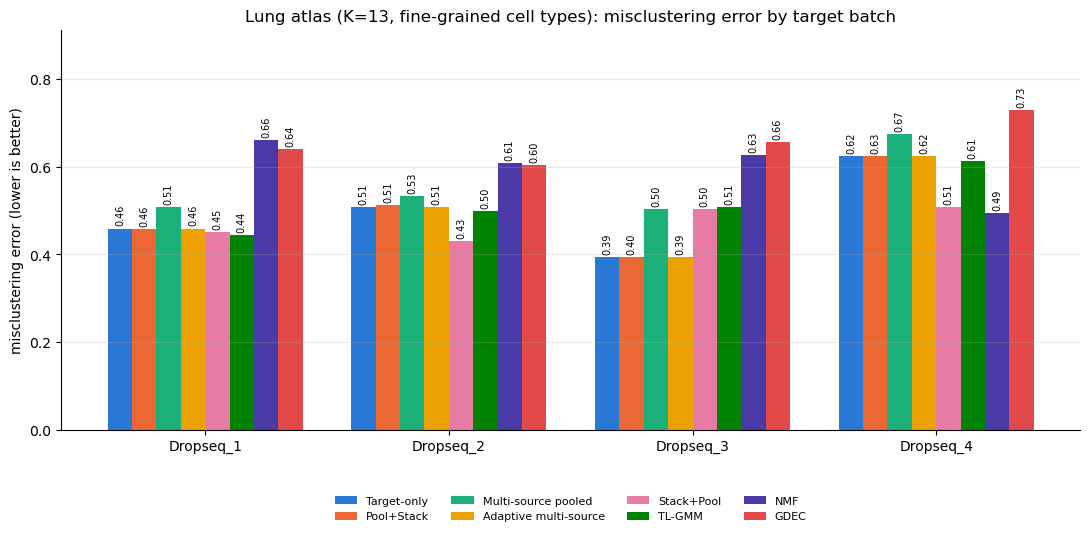

Wrote results_0.5_alpha/stack_pool/lung_atlas_ari.pdf


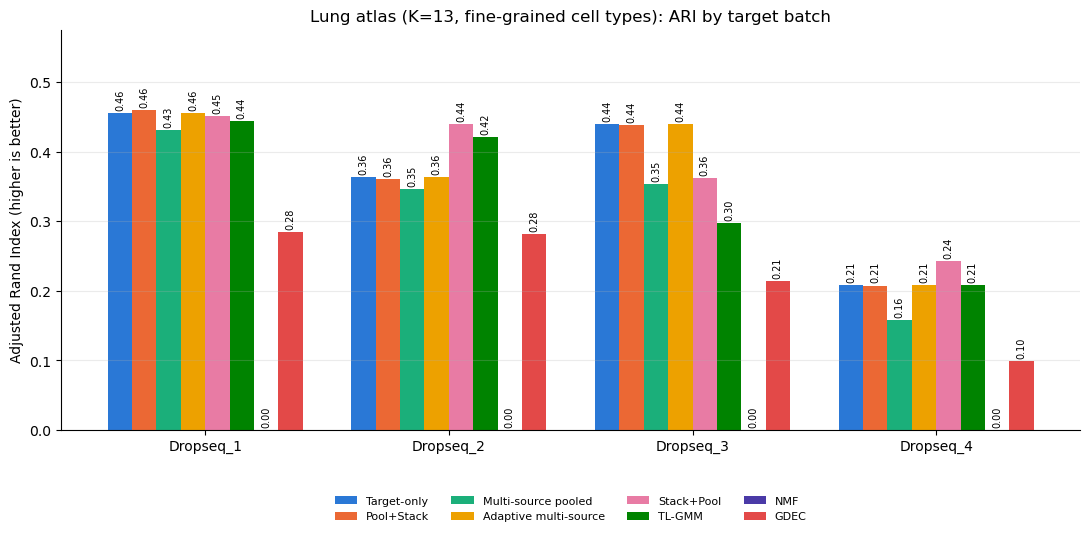

In [5]:
METHOD_COLORS = {
    "target_only": "#2a78d6",             # slot 1 blue
    "target_source_pooled": "#eb6834",    # slot 2 orange ("Pool+Stack")
    "multi_source_pooled": "#1baf7a",     # slot 3 aqua
    "adaptive_multi_source": "#eda100",   # slot 4 yellow
    "pooled_concat": "#e87ba4",           # slot 5 magenta ("Stack+Pool")
    "tlgmm": "#008300",                   # slot 6 green
    "scrna": "#4a3aa7",                   # slot 7 violet
    "gdec_gcnfree": "#e34948",            # slot 8 red
}
# Canonical validated-palette order -- determines bar left-to-right order,
# independent of the tables above (which use common.METHOD_LABELS' order).
METHOD_ORDER = list(METHOD_COLORS.keys())


def plot_metric_bar_chart(metric: str, ylabel: str, title_suffix: str, out_name: str):
    pivot = results_all.pivot(index="method", columns="target", values=metric).reindex(
        index=METHOD_ORDER, columns=common.BATCHES
    )

    n_methods = len(METHOD_ORDER)
    x = np.arange(len(common.BATCHES))
    width = 0.8 / n_methods

    fig, ax = plt.subplots(figsize=(11, 5.5))
    for i, method in enumerate(METHOD_ORDER):
        offset = (i - (n_methods - 1) / 2) * width
        vals = pivot.loc[method].values
        bars = ax.bar(x + offset, vals, width, label=LABELS[method], color=METHOD_COLORS[method])
        ax.bar_label(bars, fmt="%.2f", padding=2, fontsize=7, rotation=90)

    ax.set_xticks(x)
    ax.set_xticklabels(common.BATCHES)
    ax.set_ylabel(ylabel)
    ax.set_title(f"Lung atlas (K=13, fine-grained cell types): {title_suffix} by target batch")
    ymin = min(0.0, pivot.values.min() * 1.1)
    ax.set_ylim(ymin, max(pivot.values.max() * 1.25, 0.05))
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(True, axis="y", alpha=0.25)
    ax.legend(frameon=False, fontsize=8, ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.14))
    fig.tight_layout()

    fig_path = os.path.join(OUT_DIR, out_name)
    fig.savefig(fig_path, bbox_inches="tight")
    print(f"Wrote {fig_path}")
    plt.show()


plot_metric_bar_chart("misclustering", "misclustering error (lower is better)",
                       "misclustering error", "lung_atlas_misclustering.pdf")
plot_metric_bar_chart("ari", "Adjusted Rand Index (higher is better)",
                       "ARI", "lung_atlas_ari.pdf")